In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "지점": [
        "강남", "강남", "강남", "홍대", "홍대",
        "홍대", "종로", "종로", "종로", "종로"
    ],
    "메뉴": [
        "아메리카노", "라떼", "케이크",
        "아메리카노", "라떼", "케이크",
        "아메리카노", "라떼", "케이크", "아메리카노"
    ],
    "가격": [
        4500, 5500, 7000,
        4500, 5500, 7000,
        4500, 5500, 7000, 4500
    ],
    "판매량": [
        120, 80, 30,
        150, 60, 45,
        90, 100, 25, 110
    ],
    "평점": [
        4.5, 4.2, 4.8,
        4.7, 3.9, 4.6,
        4.1, np.nan, 4.9, 4.3
    ]
}

df = pd.DataFrame(data)

In [11]:
# df의 행/열 개수, 컬럼 이름, 각 컬럼의 자료형을 확인하세요.
df.head()
df.dtypes

지점         str
메뉴         str
가격       int64
판매량      int64
평점     float64
dtype: object

In [15]:
# 처음 5개의 데이터만 출력하세요.
df[["지점", "메뉴", "판매량"]]

,지점,메뉴,판매량
0,강남,아메리카노,120
1,강남,라떼,80
2,강남,케이크,30
3,홍대,아메리카노,150
4,홍대,라떼,60
5,홍대,케이크,45
6,종로,아메리카노,90
7,종로,라떼,100
8,종로,케이크,25
9,종로,아메리카노,110


In [17]:
# 판매량이 100 이상인 데이터만 추출하세요.
df_mask = df["판매량"] >= 100
df[df_mask]

,지점,메뉴,가격,판매량,평점
0,강남,아메리카노,4500,120,4.5
3,홍대,아메리카노,4500,150,4.7
7,종로,라떼,5500,100,NaN
9,종로,아메리카노,4500,110,4.3


In [22]:
# 판매량이 100 이상이면서 메뉴가 아메리카노인 데이터만 추출하세요.
df_mask  = (df["메뉴"] == "아메리카노") & (df["판매량"] >= 100)
df[df_mask]

,지점,메뉴,가격,판매량,평점
0,강남,아메리카노,4500,120,4.5
3,홍대,아메리카노,4500,150,4.7
7,종로,아메리카노,5500,100,NaN
9,종로,아메리카노,4500,110,4.3


In [10]:
# "매출"이라는 새로운 컬럼을 만드세요.
df["매출"] = df["가격"] * df["판매량"]
df

,지점,메뉴,가격,판매량,평점,매출
0,강남,아메리카노,4500,120,4.5,540000
1,강남,라떼,5500,80,4.2,440000
2,강남,케이크,7000,30,4.8,210000
3,홍대,아메리카노,4500,150,4.7,675000
4,홍대,라떼,5500,60,3.9,330000
5,홍대,케이크,7000,45,4.6,315000
6,종로,아메리카노,4500,90,4.1,405000
7,종로,라떼,5500,100,NaN,550000
8,종로,케이크,7000,25,4.9,175000
9,종로,아메리카노,4500,110,4.3,495000


In [36]:
# 매출이 가장 높은 행을 찾아서 지점, 메뉴, 매출을 출력하세요. 지금 배운 max()나 argmax()/idxmax() 등을 생각해보세요.


In [15]:
# groupby()를 이용해서 지점별 총 매출을 구하세요.
df.groupby("지점").sum()["매출"]
df.groupby("지점")["매출"].sum()

지점
강남    1190000
종로    1625000
홍대    1320000
Name: 매출, dtype: int64

In [22]:
# roupby()를 이용해서 메뉴별 평균 판매량을 구하세요.
round(df.groupby("메뉴")["판매량"].mean(), 2)

메뉴
라떼        80.00
아메리카노    117.50
케이크       33.33
Name: 판매량, dtype: float64

In [50]:
# 지점별로 데이터가 몇 개씩 있는지 구하세요.
df.groupby("지점").size()

지점
강남    3
종로    4
홍대    3
dtype: int64

In [49]:
# "평점"에 결측값(NaN)이 몇 개 있는지 확인하세요.
df["평점"].isna().sum()

np.int64(1)

In [59]:
# apply()와 함수를 이용해서 "평가"라는 파생변수를 만드세요.
# 평점이 NaN → "평가 없음"
# 평점 >= 4.5 → "우수"
# 나머지 → "보통"

def df_score(score):
    if pd.isna(score):
        return "평가 없음"
    if score >= 4.5:
        return "우수"
    else:
        return "보통"

df["평가"] = df["평점"].apply(df_score)
df

,지점,메뉴,가격,판매량,평점,매출,평가
0,강남,아메리카노,4500,120,4.5,540000,우수
1,강남,라떼,5500,80,4.2,440000,보통
2,강남,케이크,7000,30,4.8,210000,우수
3,홍대,아메리카노,4500,150,4.7,675000,우수
4,홍대,라떼,5500,60,3.9,330000,보통
5,홍대,케이크,7000,45,4.6,315000,우수
6,종로,아메리카노,4500,90,4.1,405000,보통
7,종로,라떼,5500,100,NaN,550000,평가 없음
8,종로,케이크,7000,25,4.9,175000,우수
9,종로,아메리카노,4500,110,4.3,495000,보통


In [67]:
# 전체 판매량의 평균, 편차, 편차의 제곱, 분산, 표준편차를 직접 구해보세요. 처음부터 std()를 쓰지 말고 지금 배운 방식으로 계산합니다.
mean = df["판매량"].mean()
print(df["판매량"] - mean)
df["편차제곱"] = (df["판매량"] - mean) ** 2
df["편차제곱"].mean() ** 0.5

0    39.0
1    -1.0
2   -51.0
3    69.0
4   -21.0
5   -36.0
6     9.0
7    19.0
8   -56.0
9    29.0
Name: 판매량, dtype: float64


np.float64(38.781438859330635)

In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [3]:
base_path = r"E:\kdt_0900_sal\data_analysis\resource\dataset"
file_name = r"hr_employee_attrition.csv"

file_path = os.path.join(base_path, file_name)

In [4]:
hr_df = pd.read_csv(file_path)
hr_df

,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


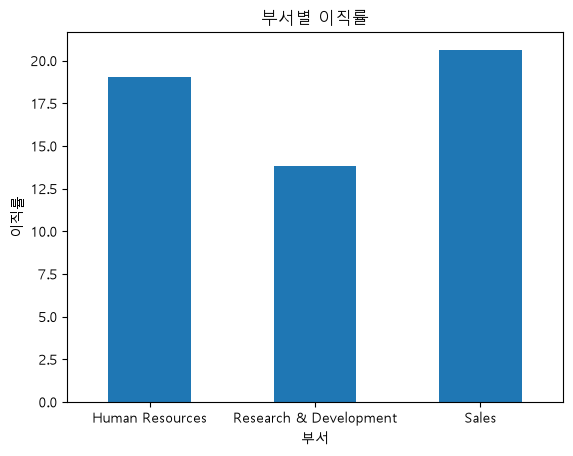

In [21]:
# ==============================================================================
# [실습 문제 1] 부서별(Department) 이직률 분석
# ==============================================================================
# 1. 부서별(Department) 이직 여부(Attrition)의 비율(%) 구하기
# 2. 부서별 이직률을 비교할 수 있는 막대 그래프(Bar plot) 시각화
# 3. 가장 이직률이 높은 부서 간단히 작성

department_attrition = hr_df.groupby("Department")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
department_attrition.plot(kind="bar")
plt.title("부서별 이직률")
plt.xlabel("부서")
plt.ylabel("이직률")
plt.xticks(rotation=0)
plt.show()

In [5]:
# ==============================================================================
# [실습 문제 2] 총 경력(TotalWorkingYears)과 월소득(MonthlyIncome)의 관계
# ==============================================================================
# 1. x축: TotalWorkingYears, y축: MonthlyIncome 산점도(Scatter plot) 그리기
# 2. 이직 여부(Attrition)에 따라 점 색상 다르게 표현 (hue='Attrition')
# 3. 경력과 월소득의 상관관계 및 이직자 분포 특징 서술

In [ ]:
# ==============================================================================
# [실습 문제 3] 직무 만족도 & 환경 만족도 복합 분석
# ==============================================================================
# 1. JobSatisfaction과 EnvironmentSatisfaction 조합별 이직률 히트맵(Heatmap) 그리기
# 2. 어떤 만족도 조합에서 이직률이 가장 높은지 서술

In [ ]:
# ==============================================================================
# [실습 문제 4] 나이(Age) 구간별 이직 위험도 파악
# ==============================================================================
# 1. Age 컬럼으로 '20대 이하', '30대', '40대', '50대 이상' 파생변수 'AgeGroup' 생성
# 2. 연령대 그룹별 이직률(%) 계산 후 시각화 (Barplot 또는 Lineplot)
# 3. 이직 위험도가 가장 높은 연령대 서술